In [2]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm
import h5py

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import sys
sys.path.append("..") 

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [3]:
from UCI.pre_processing import extract_bp_from_abp, process_recording, process_split, load_UCI_dataset, create_dataloaders

In [4]:
X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset()

Total recordings: 12000
Train recordings: 8640
Validation recordings: 960
Test recordings: 2400


100%|██████████| 8640/8640 [01:40<00:00, 86.09it/s] 


Skipped recordings: 4


100%|██████████| 960/960 [00:11<00:00, 82.85it/s] 


Skipped recordings: 0


100%|██████████| 2400/2400 [00:29<00:00, 82.61it/s] 


Skipped recordings: 1


In [5]:
X_train = torch.tensor(X_train,dtype=torch.float32)
X_val = torch.tensor(X_val,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)
y_val = torch.tensor(y_val,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

/tmp/ipykernel_1649719/1851050337.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train,dtype=torch.float32)
/tmp/ipykernel_1649719/1851050337.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_val = torch.tensor(X_val,dtype=torch.float32)
/tmp/ipykernel_1649719/1851050337.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test,dtype=torch.float32)
/tmp/ipykernel_1649719/1851050337.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clo

In [6]:
train_loader, val_loader, test_loader = create_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test)

In [7]:
from models.Resnet import ResNet1D

model = ResNet1D().to(device)
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [7]:
from models.train import train_model
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 2221.32 (SBP RMSE: 42.36, DBP RMSE: 20.66) | Val MSE: 476.03 (SBP RMSE: 19.32, DBP RMSE: 10.15)
Epoch 2/50 | Train MSE: 754.41 (SBP RMSE: 24.12, DBP RMSE: 13.13) | Val MSE: 426.90 (SBP RMSE: 18.23, DBP RMSE: 9.72)
Epoch 3/50 | Train MSE: 675.34 (SBP RMSE: 22.78, DBP RMSE: 12.50) | Val MSE: 426.54 (SBP RMSE: 18.33, DBP RMSE: 9.51)
Epoch 4/50 | Train MSE: 617.05 (SBP RMSE: 21.66, DBP RMSE: 12.17) | Val MSE: 392.51 (SBP RMSE: 17.47, DBP RMSE: 9.34)
Epoch 5/50 | Train MSE: 587.08 (SBP RMSE: 21.08, DBP RMSE: 11.95) | Val MSE: 375.35 (SBP RMSE: 16.99, DBP RMSE: 9.31)
Epoch 6/50 | Train MSE: 566.14 (SBP RMSE: 20.64, DBP RMSE: 11.83) | Val MSE: 368.36 (SBP RMSE: 17.00, DBP RMSE: 8.90)
Epoch 7/50 | Train MSE: 551.04 (SBP RMSE: 20.35, DBP RMSE: 11.71) | Val MSE: 382.40 (SBP RMSE: 17.28, DBP RMSE: 9.16)
Epoch 8/50 | Train MSE: 537.31 (SBP RMSE: 20.07, DBP RMSE: 11.59) | Val MSE: 366.30 (SBP RMSE: 16.90, DBP RMSE: 8.98)
Epoch 9/50 | Train MSE: 525.92 (SBP RMSE: 19.85, DBP R

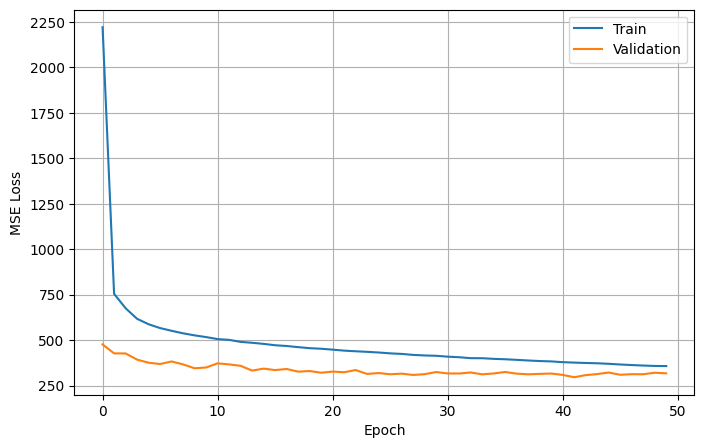

In [8]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [ ]:
from models.train import evaluate_model
predictions, targets, metrics = evaluate_model(
    model,
    test_loader,
    device
)

Predictions shape: (133841, 2)
Targets shape: (133841, 2)
SBP MAE: 11.13 mmHg
DBP MAE: 5.87 mmHg
SBP RMSE: 15.71 mmHg
DBP RMSE: 8.80 mmHg


: 

## Adding dialation ##

In [9]:
# -----------------------------
# Dilated Residual Block
# -----------------------------

class DilatedResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1, dilation=1):

        super().__init__()


        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=dilation,
            dilation=dilation,
            bias=False
        )

        self.bn1 = nn.BatchNorm1d(out_channels)


        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=dilation,
            dilation=dilation,
            bias=False
        )

        self.bn2 = nn.BatchNorm1d(out_channels)


        self.relu = nn.ReLU()


        # Skip connection
        if stride != 1 or in_channels != out_channels:

            self.shortcut = nn.Sequential(

                nn.Conv1d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm1d(out_channels)
            )

        else:
            self.shortcut = nn.Identity()



    def forward(self, x):

        identity = self.shortcut(x)


        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)


        out = self.conv2(out)
        out = self.bn2(out)


        out += identity

        out = self.relu(out)


        return out



# -----------------------------
# Dilated ResNet1D
# -----------------------------

class ResNet1D_Dilated(nn.Module):

    def __init__(self):

        super().__init__()


        self.stem = nn.Sequential(

            nn.Conv1d(
                1,
                32,
                kernel_size=7,
                stride=2,
                padding=3,
                bias=False
            ),

            nn.BatchNorm1d(32),

            nn.ReLU(),

            nn.MaxPool1d(
                kernel_size=3,
                stride=2,
                padding=1
            )
        )



        self.layer1 = nn.Sequential(

            DilatedResidualBlock(
                32,
                32,
                dilation=1
            ),

            DilatedResidualBlock(
                32,
                32,
                dilation=1
            )
        )



        self.layer2 = nn.Sequential(

            DilatedResidualBlock(
                32,
                64,
                stride=2,
                dilation=2
            ),

            DilatedResidualBlock(
                64,
                64,
                dilation=2
            )
        )



        self.layer3 = nn.Sequential(

            DilatedResidualBlock(
                64,
                128,
                stride=2,
                dilation=4
            ),

            DilatedResidualBlock(
                128,
                128,
                dilation=4
            )
        )



        self.pool = nn.AdaptiveAvgPool1d(1)


        self.fc = nn.Sequential(

            nn.Linear(128,64),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(64,2)

        )



    def forward(self,x):

        # x:
        # (batch,1,1000)

        x = self.stem(x)


        x = self.layer1(x)

        x = self.layer2(x)

        x = self.layer3(x)


        x = self.pool(x)


        x = torch.flatten(x,1)


        x = self.fc(x)


        return x

In [10]:
model = ResNet1D_Dilated().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)


model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 1705.50 (SBP RMSE: 36.76, DBP RMSE: 18.82) | Val MSE: 429.72 (SBP RMSE: 18.34, DBP RMSE: 9.67)
Epoch 2/50 | Train MSE: 584.41 (SBP RMSE: 21.13, DBP RMSE: 11.75) | Val MSE: 411.89 (SBP RMSE: 17.98, DBP RMSE: 9.41)
Epoch 3/50 | Train MSE: 539.69 (SBP RMSE: 20.18, DBP RMSE: 11.50) | Val MSE: 373.18 (SBP RMSE: 16.92, DBP RMSE: 9.31)
Epoch 4/50 | Train MSE: 500.30 (SBP RMSE: 19.38, DBP RMSE: 11.18) | Val MSE: 368.80 (SBP RMSE: 16.93, DBP RMSE: 9.06)
Epoch 5/50 | Train MSE: 475.42 (SBP RMSE: 18.81, DBP RMSE: 11.02) | Val MSE: 363.73 (SBP RMSE: 16.76, DBP RMSE: 9.10)
Epoch 6/50 | Train MSE: 459.33 (SBP RMSE: 18.46, DBP RMSE: 10.88) | Val MSE: 361.21 (SBP RMSE: 16.84, DBP RMSE: 8.81)
Epoch 7/50 | Train MSE: 442.97 (SBP RMSE: 18.10, DBP RMSE: 10.74) | Val MSE: 355.17 (SBP RMSE: 16.62, DBP RMSE: 8.89)
Epoch 8/50 | Train MSE: 429.32 (SBP RMSE: 17.81, DBP RMSE: 10.58) | Val MSE: 358.34 (SBP RMSE: 16.73, DBP RMSE: 8.85)
Epoch 9/50 | Train MSE: 420.64 (SBP RMSE: 17.63, DBP RM

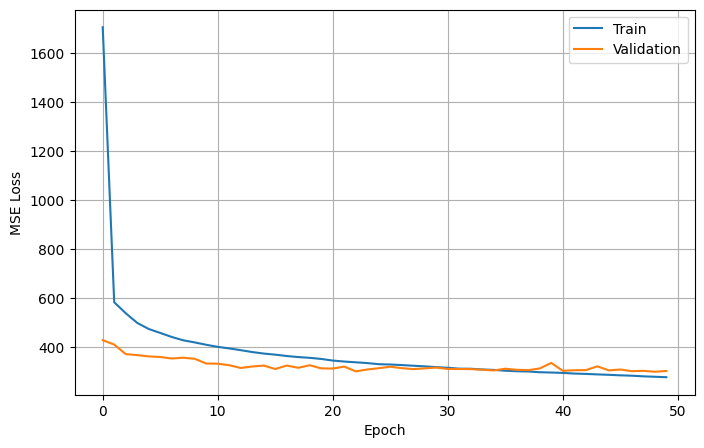

In [11]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [12]:
from models.train import evaluate_model
predictions, targets, metrics = evaluate_model(
    model,
    test_loader,
    device
)

Predictions shape: (133841, 2)
Targets shape: (133841, 2)
SBP MAE: 11.13 mmHg
DBP MAE: 5.87 mmHg
SBP RMSE: 15.71 mmHg
DBP RMSE: 8.80 mmHg


## Adding SE (Squeeze and Excitation) Attention ##

In [8]:
from models.Resnet import SEResNet1D

model = SEResNet1D().to(device)
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [10]:
from models.train import train_model
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 2010.65 (SBP RMSE: 40.11, DBP RMSE: 20.05) | Val MSE: 458.72 (SBP RMSE: 18.97, DBP RMSE: 9.95)
Epoch 2/50 | Train MSE: 667.60 (SBP RMSE: 22.64, DBP RMSE: 12.45) | Val MSE: 422.22 (SBP RMSE: 18.08, DBP RMSE: 9.77)
Epoch 3/50 | Train MSE: 615.06 (SBP RMSE: 21.62, DBP RMSE: 12.15) | Val MSE: 398.04 (SBP RMSE: 17.47, DBP RMSE: 9.63)
Epoch 4/50 | Train MSE: 581.87 (SBP RMSE: 20.96, DBP RMSE: 11.94) | Val MSE: 382.53 (SBP RMSE: 17.17, DBP RMSE: 9.37)
Epoch 5/50 | Train MSE: 555.19 (SBP RMSE: 20.42, DBP RMSE: 11.75) | Val MSE: 386.50 (SBP RMSE: 17.35, DBP RMSE: 9.24)
Epoch 6/50 | Train MSE: 537.62 (SBP RMSE: 20.06, DBP RMSE: 11.63) | Val MSE: 371.49 (SBP RMSE: 16.88, DBP RMSE: 9.30)
Epoch 7/50 | Train MSE: 520.84 (SBP RMSE: 19.72, DBP RMSE: 11.48) | Val MSE: 359.20 (SBP RMSE: 16.61, DBP RMSE: 9.12)
Epoch 8/50 | Train MSE: 505.14 (SBP RMSE: 19.40, DBP RMSE: 11.34) | Val MSE: 359.88 (SBP RMSE: 16.69, DBP RMSE: 9.02)
Epoch 9/50 | Train MSE: 491.02 (SBP RMSE: 19.10, DBP RM

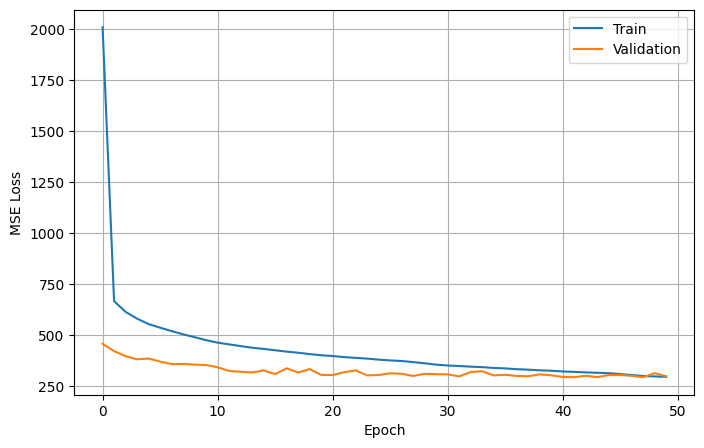

In [11]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [12]:
from models.train import evaluate_model
predictions, targets, metrics = evaluate_model(
    model,
    test_loader,
    device
)

SBP MAE: 10.74 mmHg
DBP MAE: 5.96 mmHg
SBP RMSE: 15.57 mmHg
DBP RMSE: 8.77 mmHg


## Using ResNet18 ##

In [13]:
from models.Resnet import ResNet18_1D

model = ResNet18_1D().to(device)
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [14]:
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 1860.46 (SBP RMSE: 39.54, DBP RMSE: 17.24) | Val MSE: 368.55 (SBP RMSE: 17.00, DBP RMSE: 8.91)
Epoch 2/50 | Train MSE: 289.63 (SBP RMSE: 14.72, DBP RMSE: 8.53) | Val MSE: 351.58 (SBP RMSE: 16.73, DBP RMSE: 8.46)
Epoch 3/50 | Train MSE: 237.02 (SBP RMSE: 13.22, DBP RMSE: 7.89) | Val MSE: 355.73 (SBP RMSE: 16.83, DBP RMSE: 8.52)
Epoch 4/50 | Train MSE: 207.08 (SBP RMSE: 12.29, DBP RMSE: 7.48) | Val MSE: 314.58 (SBP RMSE: 15.71, DBP RMSE: 8.24)
Epoch 5/50 | Train MSE: 186.87 (SBP RMSE: 11.63, DBP RMSE: 7.18) | Val MSE: 326.73 (SBP RMSE: 16.06, DBP RMSE: 8.29)
Epoch 6/50 | Train MSE: 170.40 (SBP RMSE: 11.06, DBP RMSE: 6.94) | Val MSE: 306.13 (SBP RMSE: 15.44, DBP RMSE: 8.23)
Epoch 7/50 | Train MSE: 158.38 (SBP RMSE: 10.62, DBP RMSE: 6.75) | Val MSE: 321.61 (SBP RMSE: 15.83, DBP RMSE: 8.42)
Epoch 8/50 | Train MSE: 148.14 (SBP RMSE: 10.24, DBP RMSE: 6.58) | Val MSE: 314.70 (SBP RMSE: 15.24, DBP RMSE: 9.08)
Epoch 9/50 | Train MSE: 138.98 (SBP RMSE: 9.88, DBP RMSE: 6.43

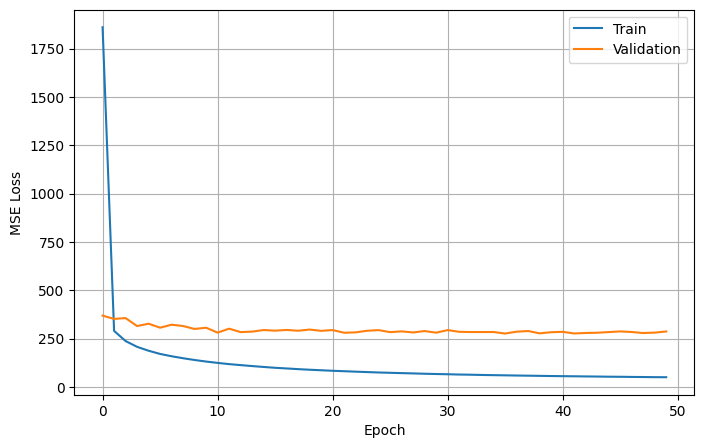

In [15]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [16]:
from models.train import evaluate_model
predictions, targets, metrics = evaluate_model(
    model,
    test_loader,
    device
)

SBP MAE: 10.24 mmHg
DBP MAE: 5.44 mmHg
SBP RMSE: 15.06 mmHg
DBP RMSE: 8.36 mmHg


## ResNet18 + SE Attention ##

In [17]:
from models.Resnet import SEResNet18_1D

model = SEResNet18_1D().to(device)
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [20]:
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 1950.81 (SBP RMSE: 40.62, DBP RMSE: 17.34) | Val MSE: 417.72 (SBP RMSE: 18.19, DBP RMSE: 9.31)
Epoch 2/50 | Train MSE: 356.94 (SBP RMSE: 16.45, DBP RMSE: 9.29) | Val MSE: 362.25 (SBP RMSE: 16.82, DBP RMSE: 8.90)
Epoch 3/50 | Train MSE: 274.21 (SBP RMSE: 14.26, DBP RMSE: 8.42) | Val MSE: 338.95 (SBP RMSE: 15.80, DBP RMSE: 9.46)
Epoch 4/50 | Train MSE: 227.08 (SBP RMSE: 12.88, DBP RMSE: 7.82) | Val MSE: 314.87 (SBP RMSE: 15.67, DBP RMSE: 8.33)
Epoch 5/50 | Train MSE: 196.57 (SBP RMSE: 11.90, DBP RMSE: 7.41) | Val MSE: 326.73 (SBP RMSE: 16.02, DBP RMSE: 8.37)
Epoch 6/50 | Train MSE: 175.19 (SBP RMSE: 11.19, DBP RMSE: 7.06) | Val MSE: 293.49 (SBP RMSE: 14.98, DBP RMSE: 8.32)
Epoch 7/50 | Train MSE: 158.28 (SBP RMSE: 10.59, DBP RMSE: 6.79) | Val MSE: 283.17 (SBP RMSE: 14.75, DBP RMSE: 8.10)
Epoch 8/50 | Train MSE: 145.07 (SBP RMSE: 10.10, DBP RMSE: 6.56) | Val MSE: 283.77 (SBP RMSE: 14.78, DBP RMSE: 8.09)
Epoch 9/50 | Train MSE: 134.00 (SBP RMSE: 9.67, DBP RMSE: 6.37

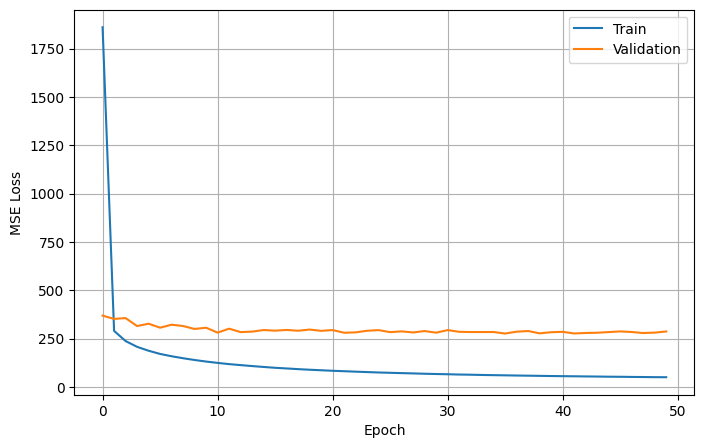

In [18]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [19]:
from models.train import evaluate_model
predictions, targets, metrics = evaluate_model(
    model,
    test_loader,
    device
)

SBP MAE: 130.47 mmHg
DBP MAE: 67.07 mmHg
SBP RMSE: 132.37 mmHg
DBP RMSE: 68.04 mmHg
